# Clustering Techniques

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN



In [3]:
# Load the dataset
data = pd.read_csv('../datasets/city_day.csv')
# Display the first few rows of the dataset
print(data.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [28]:
# Check for missing values and handle them if necessary
print(data.isnull().sum())
data.dropna(inplace=True)  # Drop rows with missing values

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['PM2.5', 'AQI']])
scaled_data = pd.DataFrame(scaled_data, columns=['PM2.5', 'AQI'])
# Check the scaled data
print(scaled_data.head())


City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
Cluster       0
dtype: int64
      PM2.5       AQI
0  0.373755  0.468988
1  0.316405  0.609178
2  0.510799  0.619962
3  0.053116  0.512123
4  0.207477  0.350366


In [37]:
# Select 'NO' and 'PM2.5' features
features = data[['NO', 'PM2.5']].dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(scaled_features)

# Add the cluster labels to the original data
data['Cluster'] = -1
data.loc[features.index, 'Cluster'] = clusters

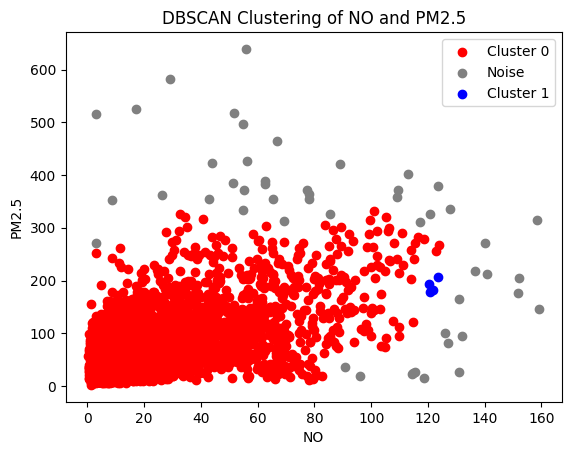

Estimated number of clusters: 2
Estimated number of noise points: 50


In [35]:
import seaborn as sns

# Plot scatter plot with color bar

unique_clusters = data['Cluster'].unique()
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

for i, cluster in enumerate(unique_clusters):
    if cluster != -1:  # Ignore noise points
        plt.scatter(data.loc[data['Cluster'] == cluster, 'NO'],
                    data.loc[data['Cluster'] == cluster, 'PM2.5'],
                    color=colors[i % len(colors)], label=f'Cluster {cluster}')
    else:
        plt.scatter(data.loc[data['Cluster'] == cluster, 'NO'],
                    data.loc[data['Cluster'] == cluster, 'PM2.5'],
                    color='gray', label='Noise')
        
plt.xlabel('NO')
plt.ylabel('PM2.5')
plt.title('DBSCAN Clustering of NO and PM2.5')
plt.legend()
plt.show()

# Number of clusters and noise points
n_clusters = len(unique_clusters) - 1  # Exclude noise
print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of noise points: {sum(clusters == -1)}')
